In [1]:
# P.A.-1: Diabetes Risk and Patient Health Analytics
# HA-702: Python for Analytics
# Synthetic dataset: diabetes_risk_20_records.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)


In [2]:
# PART 1 - DATASET LOADING AND INITIAL EXPLORATION
df = pd.read_csv("C:/Users/anike/OneDrive/2 YEAR HA/Python fo analytics/Assignment/diabetes_risk_records.csv")

print("First 10 records")
print(df.head(10))

First 10 records
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1      148             72             35        0  33.6   
1            3       85             66             29        0  26.6   
2            2      183             64              0        0  23.3   
3            4      137             74             30      168  33.2   
4            0      126             88             41      250  39.0   
5            1       99             68             20       90  27.8   
6            5      170             78             35      220  35.5   
7            2      110             70             25      100  31.2   
8            6      145             82              0        0  37.1   
9            1      115             64             30      115  29.5   

   DiabetesPedigreeFunction  Age  Gender  Outcome  
0                     0.477   50  Female        1  
1                     0.340   31  Female        0  
2                     0.358   32  

In [3]:
print(df.tail(5))

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
15            2      160             84             36      210  38.5   
16            9      200             92             42      350  45.2   
17            1      108             70             27      100  24.8   
18            5      175             86             39      260  40.0   
19            3      120             72             28      110  30.1   

    DiabetesPedigreeFunction  Age  Gender  Outcome  
15                     0.650   54  Female        1  
16                     0.134   58    Male        1  
17                     0.245   30  Female        0  
18                     0.695   47    Male        1  
19                     0.403   36    Male        0  


In [4]:
print(df.shape)

(20, 10)


In [5]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Gender', 'Outcome']


In [6]:
print(df.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Gender                       object
Outcome                       int64
dtype: object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               20 non-null     int64  
 1   Glucose                   20 non-null     int64  
 2   BloodPressure             20 non-null     int64  
 3   SkinThickness             20 non-null     int64  
 4   Insulin                   20 non-null     int64  
 5   BMI                       20 non-null     float64
 6   DiabetesPedigreeFunction  20 non-null     float64
 7   Age                       20 non-null     int64  
 8   Gender                    20 non-null     object 
 9   Outcome                   20 non-null     int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 1.7+ KB


In [8]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count    20.000000   20.000000      20.000000      20.000000   20.000000   
mean      3.350000  137.700000      74.900000      28.100000  136.600000   
std       2.621269   34.186947       9.743554      11.629816  102.345853   
min       0.000000   85.000000      60.000000       0.000000    0.000000   
25%       1.000000  109.500000      67.500000      24.500000   88.750000   
50%       3.000000  134.500000      73.000000      30.000000  112.500000   
75%       5.000000  162.500000      82.500000      35.250000  212.500000   
max       9.000000  200.000000      92.000000      42.000000  350.000000   

             BMI  DiabetesPedigreeFunction        Age    Outcome  
count  20.000000                 20.000000  20.000000  20.000000  
mean   32.430000                  0.453200  41.300000   0.550000  
std     6.519937                  0.224091  11.383737   0.510418  
min    22.500000                  0.106000  24.

In [10]:
# PART 2 - DATA CLEANING
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Gender                      0
Outcome                     0
dtype: int64


In [11]:
print(df.duplicated().sum())

0


In [12]:
clinical_cols = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]

df[clinical_cols] = df[clinical_cols].replace(0, np.nan)

In [13]:
for col in clinical_cols:
    df[col] = df[col].fillna(df[col].median())

In [14]:
print(df)

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0             1      148             72           35.0    140.0  33.6   
1             3       85             66           29.0    140.0  26.6   
2             2      183             64           31.0    140.0  23.3   
3             4      137             74           30.0    168.0  33.2   
4             0      126             88           41.0    250.0  39.0   
5             1       99             68           20.0     90.0  27.8   
6             5      170             78           35.0    220.0  35.5   
7             2      110             70           25.0    100.0  31.2   
8             6      145             82           31.0    140.0  37.1   
9             1      115             64           30.0    115.0  29.5   
10            8      190             90           37.0    300.0  42.1   
11            3      104             62           23.0     94.0  25.3   
12            7      155             80           3

In [15]:
# PART 3 - FEATURE ENGINEERING
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"
df["BMI_Category"] = df["BMI"].apply(bmi_category)
print(df["BMI_Category"].value_counts())

BMI_Category
Obese         12
Overweight     5
Normal         3
Name: count, dtype: int64


In [16]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 50:
        return "Middle Age"
    else:
        return "Older"
df["Age_Group"] = df["Age"].apply(age_group)

print(df["Age_Group"].value_counts())


Age_Group
Middle Age    11
Older          6
Young          3
Name: count, dtype: int64


In [40]:
# PART 4 - EXPLORATORY DATA ANALYSIS
print(df["Age"].mean())
print(df["BMI"].mean())
print(df["Glucose"].mean())


41.3
32.43
137.7


In [18]:
print(df["Outcome"].value_counts().rename(index={
    0: "Non-Diabetic",
    1: "Diabetic"
}))

Outcome
Diabetic        11
Non-Diabetic     9
Name: count, dtype: int64


In [19]:
age_diabetes = df[df["Outcome"] == 1]["Age_Group"].value_counts()
print(age_diabetes)
print("Highest:", age_diabetes.idxmax())

Age_Group
Older         6
Middle Age    5
Name: count, dtype: int64
Highest: Older


In [41]:
bmi_diabetes = df[df["Outcome"] == 1]["BMI_Category"].value_counts()
print(bmi_diabetes)
print("Highest:", bmi_diabetes.idxmax())

BMI_Category
Obese     10
Normal     1
Name: count, dtype: int64
Highest: Obese


In [21]:
print(df.groupby("Outcome")["Glucose"].mean())

Outcome
0    107.222222
1    162.636364
Name: Glucose, dtype: float64


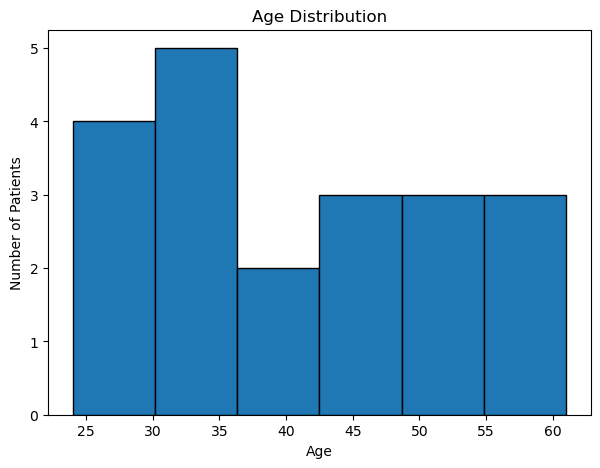

In [22]:
# PART 5 - DATA VISUALIZATION
plt.figure(figsize=(7, 5))
plt.hist(df["Age"], bins=6, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution")
plt.show()

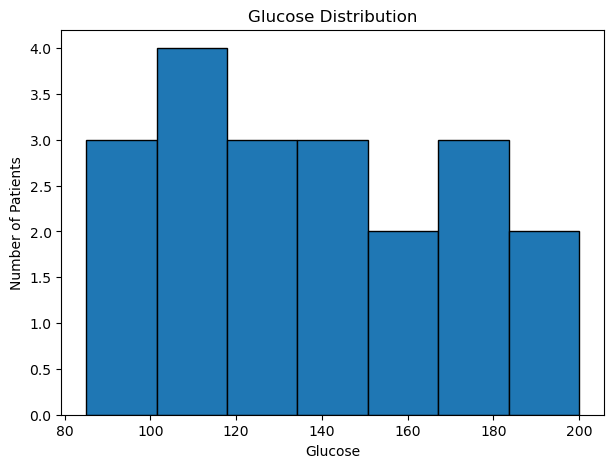

In [23]:
plt.figure(figsize=(7, 5))
plt.hist(df["Glucose"], bins=7, edgecolor="black")
plt.xlabel("Glucose")
plt.ylabel("Number of Patients")
plt.title("Glucose Distribution")
plt.show()

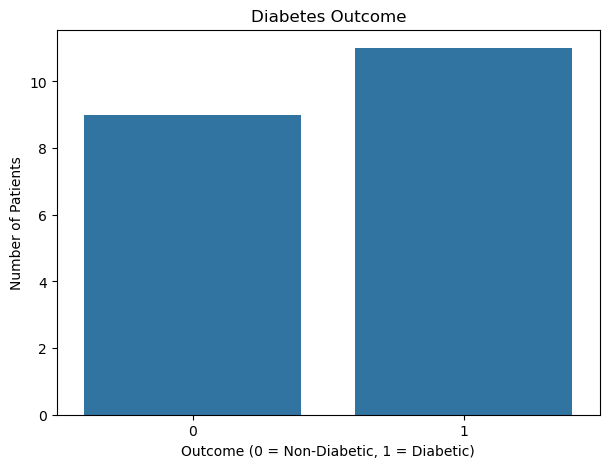

In [24]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")
plt.title("Diabetes Outcome")
plt.show()

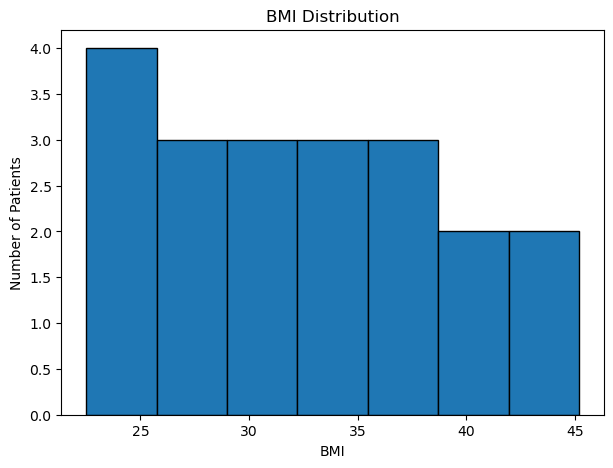

In [25]:
plt.figure(figsize=(7, 5))
plt.hist(df["BMI"], bins=7, edgecolor="black")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.title("BMI Distribution")
plt.show()

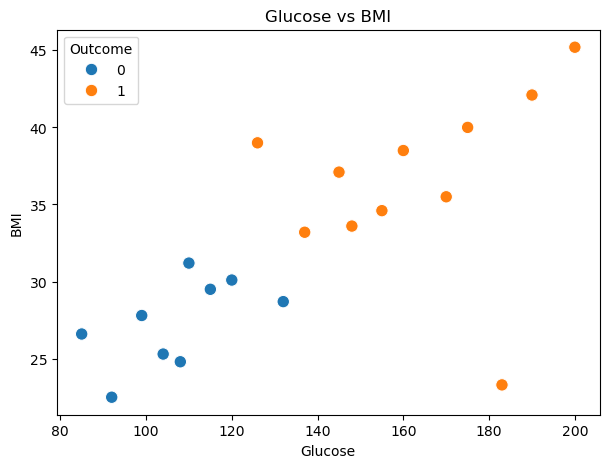

In [26]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Glucose", y="BMI", hue="Outcome", s=80)
plt.title("Glucose vs BMI")
plt.show()


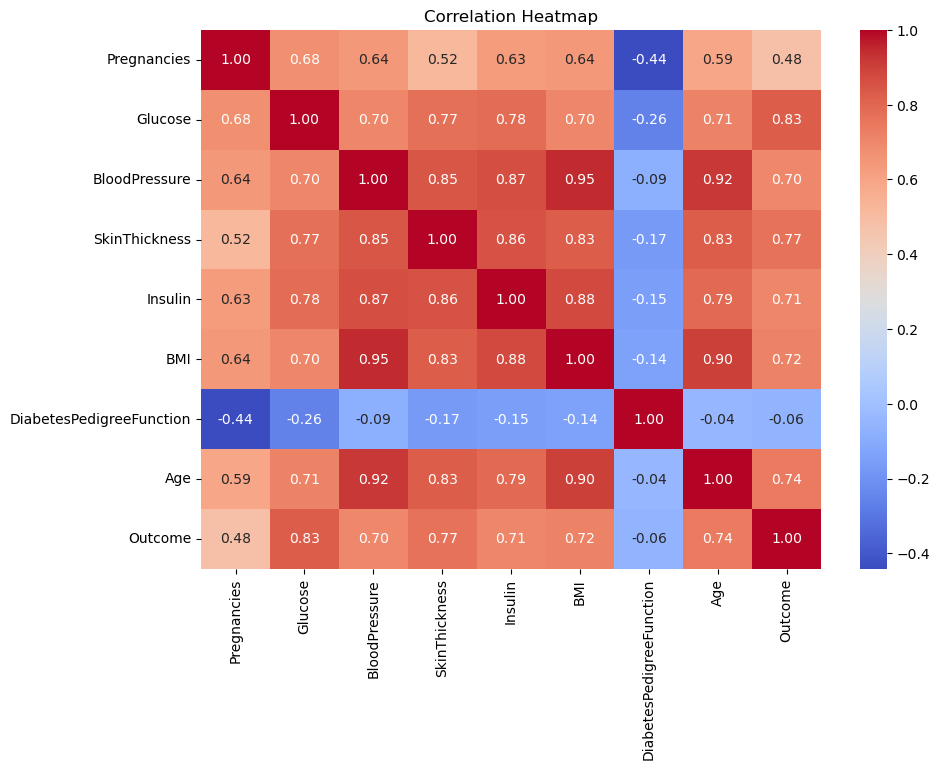

In [27]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

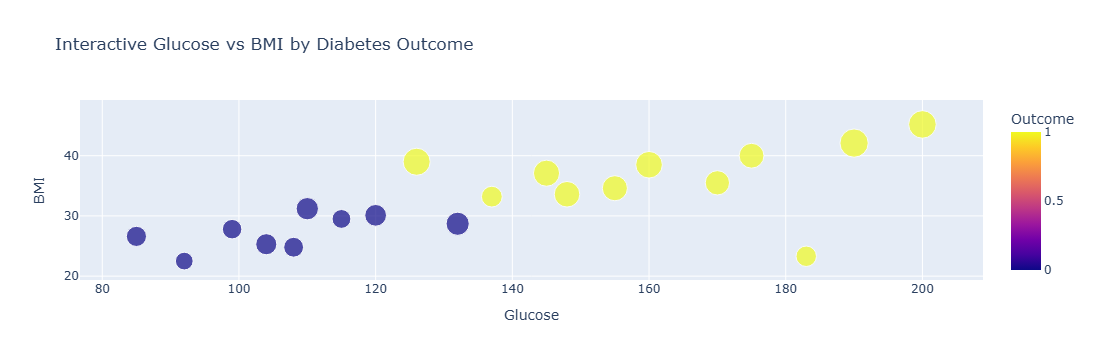

In [28]:
# Interactive Plotly visualization
import plotly.express as px

fig = px.scatter(
    df,
    x="Glucose",
    y="BMI",
    color="Outcome",
    size="Age",
    hover_data=["Gender", "Age_Group", "BMI_Category"],
    title="Interactive Glucose vs BMI by Diabetes Outcome"
)
fig.show()

In [29]:
# PART 6 - STATISTICAL ANALYSIS
# Hypothesis 1
# H0: Mean glucose level is the same for diabetic and non-diabetic patients.
# H1: Mean glucose level is different between the two groups.
diabetic_glucose = df.loc[df["Outcome"] == 1, "Glucose"]
non_diabetic_glucose = df.loc[df["Outcome"] == 0, "Glucose"]

t_stat, p_value = ttest_ind(
    diabetic_glucose,
    non_diabetic_glucose,
    equal_var=False
)
print(round(t_stat, 4))
print("p-value:", p_value)

if p_value < 0.05:
    print("Decision: Reject H0.\nInterpretation: Mean glucose levels differ significantly between groups.")
else:
    print("Decision: Fail to reject H0.\nInterpretation: No statistically significant difference was detected.")

6.5485
p-value: 5.0569779723534e-06
Decision: Reject H0.
Interpretation: Mean glucose levels differ significantly between groups.


In [30]:
# Hypothesis 2 - Gender vs diabetes outcome
gender_table = pd.crosstab(df["Gender"], df["Outcome"])
chi2, p, dof, expected = chi2_contingency(gender_table)
print(gender_table)
print(round(chi2, 4))
print(round(p, 4))

if p < 0.05:
    print("Reject H0. Gender and outcome are significantly associated.")
else:
    print("Fail to reject H0. No significant association was detected.")

Outcome  0  1
Gender       
Female   4  7
Male     5  4
0.1653
0.6843
Fail to reject H0. No significant association was detected.


In [38]:
# PART 7 - CORRELATION ANALYSIS
# Correlation between numerical variables

correlation = df.corr(numeric_only=True)

print(correlation)
print("\nStrongest positive correlation:")
print("BloodPressure, BMI")

print("\nStrongest negative correlation:")
print("Pregnancies, DiabetesPedigreeFunction")

print("\nWeakest correlation:")
print("DiabetesPedigreeFunction, Age")

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.677238       0.642324       0.516817   
Glucose                      0.677238  1.000000       0.704920       0.771429   
BloodPressure                0.642324  0.704920       1.000000       0.846429   
SkinThickness                0.516817  0.771429       0.846429       1.000000   
Insulin                      0.631868  0.781190       0.870308       0.855149   
BMI                          0.641753  0.703909       0.945022       0.829126   
DiabetesPedigreeFunction    -0.441767 -0.260258      -0.086238      -0.166546   
Age                          0.588934  0.714710       0.916086       0.830632   
Outcome                      0.477953  0.827344       0.699527       0.768219   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.631868  0.641753                 -0.441767   
Glucose                   0.781190  0.703

In [39]:
# PART 8 - MACHINE LEARNING: LOGISTIC REGRESSION
# Select features

X = df[["Pregnancies", "Glucose", "BloodPressure", 
        "SkinThickness", "Insulin", "BMI", 
        "DiabetesPedigreeFunction", "Age"]]

y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(y_pred)

[1 0 1 0 1 0]


In [37]:
# PART 9 - MODEL EVALUATION
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Accuracy Percentage: 100.0 %
Confusion Matrix:
[[3 0]
 [0 3]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [42]:
# PART 10 - HEALTHCARE RECOMMENDATIONS
print("""
Healthcare Recommendations:
1. Patients with elevated glucose should be prioritized for confirmatory
   diabetes screening and clinical follow-up.
2. BMI should be considered as one of the metabolic risk indicators,
   especially for patients in the overweight or obese categories.
3. Older and middle-age high-risk groups can be prioritized for preventive
   counselling and lifestyle interventions.
4. Patients with multiple risk indicators should receive closer monitoring
   and timely referral for clinical assessment.
""")



Healthcare Recommendations:
1. Patients with elevated glucose should be prioritized for confirmatory
   diabetes screening and clinical follow-up.
2. BMI should be considered as one of the metabolic risk indicators,
   especially for patients in the overweight or obese categories.
3. Older and middle-age high-risk groups can be prioritized for preventive
   counselling and lifestyle interventions.
4. Patients with multiple risk indicators should receive closer monitoring
   and timely referral for clinical assessment.

